# Student Academic Performance Prediction

## Mission
This project supports early academic-support outreach by predicting a student's average exam score from information that is known **before any exam is taken**: gender, race/ethnicity group, parental level of education, lunch type (a proxy for socio-economic background), and whether the student completed a test-preparation course. Because this is known in advance, schools could use a model like this to flag students who may benefit from outreach or the test-prep course itself, before scores exist.

**Dataset:** [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams) (Kaggle, cleaned version), 1000 students, 10 columns.

**Important design decision:** the raw dataset also contains `math_score`, `reading_score`, `writing_score` and `total_score`. These are dropped as predictors — `average_score` is literally computed from them (`average_score = total_score / 3 = (math+reading+writing)/3`), so including any of them would let the model 'cheat' by reconstructing the target almost perfectly instead of learning a genuine relationship. Only the five demographic/background columns are used as features.

## 1. Load and Inspect the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("students_performance.csv")
print(df.shape)
df.head()

(1000, 10)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,1,0,72,72,74,218,72.666667
1,0,group C,some college,1,1,69,90,88,247,82.333333
2,0,group B,master's degree,1,0,90,95,93,278,92.666667
3,1,group A,associate's degree,0,0,47,57,44,148,49.333333
4,1,group C,some college,1,0,76,78,75,229,76.333333


In [2]:
df.info()
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   int64  
 1   race_ethnicity               1000 non-null   str    
 2   parental_level_of_education  1000 non-null   str    
 3   lunch                        1000 non-null   int64  
 4   test_preparation_course      1000 non-null   int64  
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
dtypes: float64(1), int64(7), str(2)
memory usage: 78.3 KB

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_

No missing values. `gender`, `lunch`, and `test_preparation_course` arrive pre-encoded as 0/1 in this cleaned file; `race_ethnicity` and `parental_level_of_education` are text categories that still need encoding below.

## 2. Exploratory Visualizations

### Distribution of the target variable (`average_score`)

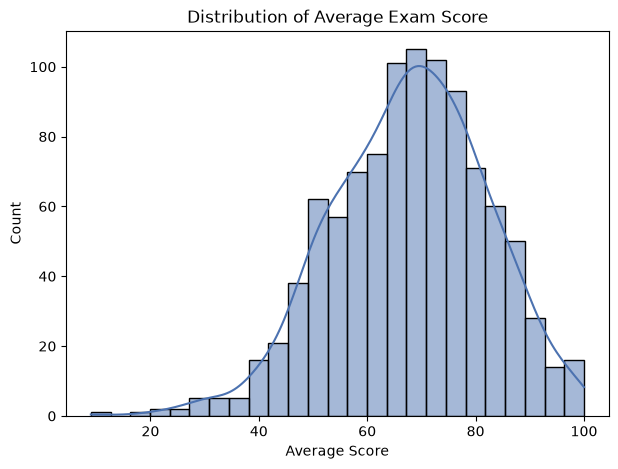

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(df["average_score"], bins=25, kde=True, color="#4C72B0")
plt.title("Distribution of Average Exam Score")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.show()

**Interpretation:** `average_score` is roughly bell-shaped, centered around the high 60s, with a slight left tail (a few low-scoring students). This is well-suited to a regression model — there's no extreme skew or outlier cluster that would need special handling.

### Correlation heatmap (numeric-encoded view)

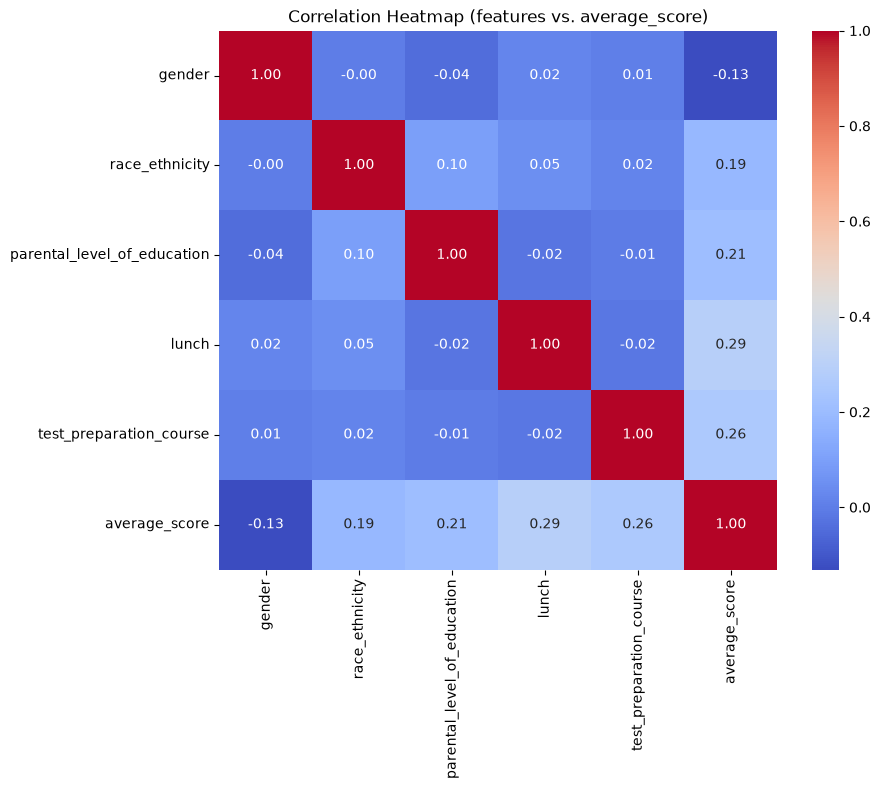

In [20]:
corr_view = df.copy()
corr_view["parental_level_of_education"] = corr_view["parental_level_of_education"].map({
    "some high school": 0, "high school": 1, "some college": 2,
    "associate's degree": 3, "bachelor's degree": 4, "master's degree": 5,
})
corr_view["race_ethnicity"] = corr_view["race_ethnicity"].astype("category").cat.codes

plt.figure(figsize=(9,7))
cols = ["gender", "race_ethnicity", "parental_level_of_education", "lunch",
        "test_preparation_course", "average_score"]
sns.heatmap(corr_view[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (features vs. average_score)")
plt.show()

**Interpretation:** `test_preparation_course` and `lunch` show the strongest correlation with `average_score` (both positive — completing the prep course and having standard lunch associate with higher scores). `parental_level_of_education` has a smaller positive correlation. `gender` and `race_ethnicity` correlate more weakly. This tells us the model's signal will come mostly from `test_preparation_course` and `lunch`, so we should not expect a very high R² from demographic features alone — average_score is mostly driven by individual ability/effort, which isn't in this dataset.

### average_score by category

/tmp/ipykernel_577/1259243294.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(["None", "Completed"])
/tmp/ipykernel_577/1259243294.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(["Free/Reduced", "Standard"])


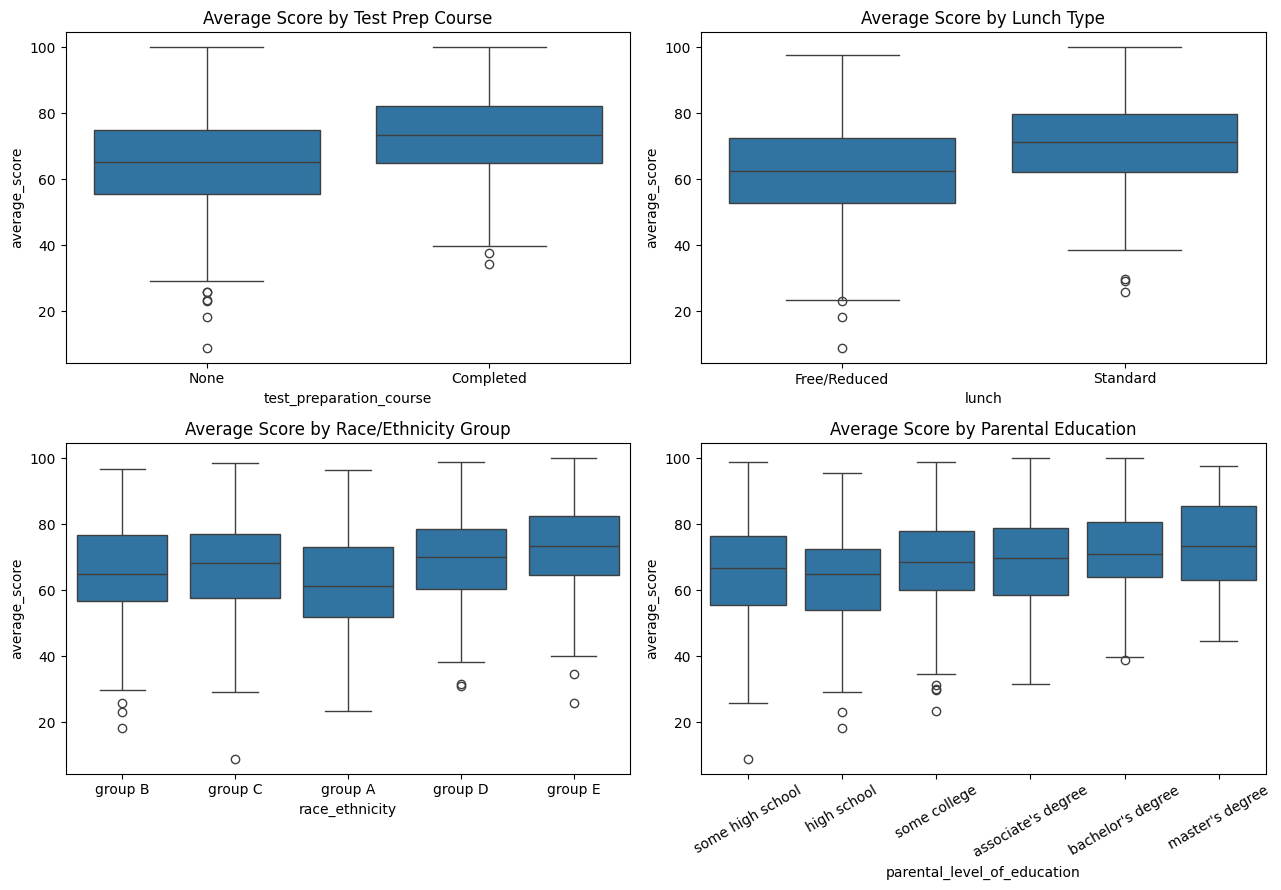

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=df, x="test_preparation_course", y="average_score", ax=axes[0,0])
axes[0,0].set_xticklabels(["None", "Completed"])
axes[0,0].set_title("Average Score by Test Prep Course")

sns.boxplot(data=df, x="lunch", y="average_score", ax=axes[0,1])
axes[0,1].set_xticklabels(["Free/Reduced", "Standard"])
axes[0,1].set_title("Average Score by Lunch Type")

sns.boxplot(data=df, x="race_ethnicity", y="average_score", ax=axes[1,0])
axes[1,0].set_title("Average Score by Race/Ethnicity Group")

order = ["some high school", "high school", "some college",
         "associate's degree", "bachelor's degree", "master's degree"]
sns.boxplot(data=df, x="parental_level_of_education", y="average_score", ax=axes[1,1], order=order)
axes[1,1].set_title("Average Score by Parental Education")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Interpretation:** completing test prep and having standard lunch both shift the whole score distribution upward, not just the average — confirming these are the strongest features. Parental education shows a mild upward trend from "some high school" to "master's degree". Race/ethnicity groups differ but with a lot of overlap, suggesting a weaker standalone effect once the other features are accounted for.

## 3. Feature Engineering

- **Dropped:** `math_score`, `reading_score`, `writing_score`, `total_score` — direct leakage of the target (see Mission note above).
- **Kept as features:** `gender`, `race_ethnicity`, `parental_level_of_education`, `lunch`, `test_preparation_course` — all known before any test is taken.
- **Numeric conversion:** `gender`, `lunch`, `test_preparation_course` already arrive as 0/1 integers in this cleaned file. `race_ethnicity` (5 groups) and `parental_level_of_education` (6 levels) are text and must be one-hot encoded, since they are nominal/ordinal categories, not raw numbers a linear model could use directly.
- **Target:** `average_score` (continuous, 0-100).

In [6]:
target = "average_score"
feature_source_cols = ["gender", "race_ethnicity", "parental_level_of_education",
                       "lunch", "test_preparation_course"]

model_df = df[feature_source_cols + [target]].copy()
model_df = pd.get_dummies(
    model_df, columns=["race_ethnicity", "parental_level_of_education"], drop_first=True
)
bool_cols = model_df.select_dtypes(include="bool").columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

feature_columns = [c for c in model_df.columns if c != target]
print("Encoded feature columns:", feature_columns)
model_df.head()

Encoded feature columns: ['gender', 'lunch', 'test_preparation_course', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school']


,gender,lunch,test_preparation_course,average_score,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school
0,0,1,0,72.666667,1,0,0,0,1,0,0,0,0
1,0,1,1,82.333333,0,1,0,0,0,0,0,1,0
2,0,1,0,92.666667,1,0,0,0,0,0,1,0,0
3,1,0,0,49.333333,0,0,0,0,0,0,0,0,0
4,1,1,0,76.333333,0,1,0,0,0,0,0,1,0


## 4. Train/Test Split and Standardization

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = model_df[feature_columns]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (800, 12) | Test shape: (200, 12)


Standardization is applied even though most features are already 0/1, because the gradient-descent (SGD) model below converges faster and more reliably on standardized inputs, and it keeps every feature on a comparable scale for the linear models' coefficients to be interpretable.

## Model 1: Linear Regression trained with Stochastic Gradient Descent

In [8]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

n_epochs = 200
sgd = SGDRegressor(max_iter=1, learning_rate="invscaling", eta0=0.01, warm_start=True, random_state=42)

train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

sgd_pred = sgd.predict(X_test_scaled)
sgd_mse = mean_squared_error(y_test, sgd_pred)
sgd_r2 = r2_score(y_test, sgd_pred)
print(f"SGD Linear Regression -> Test MSE: {sgd_mse:.3f}  R2: {sgd_r2:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

SGD Linear Regression -> Test MSE: 181.714  R2: 0.152


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

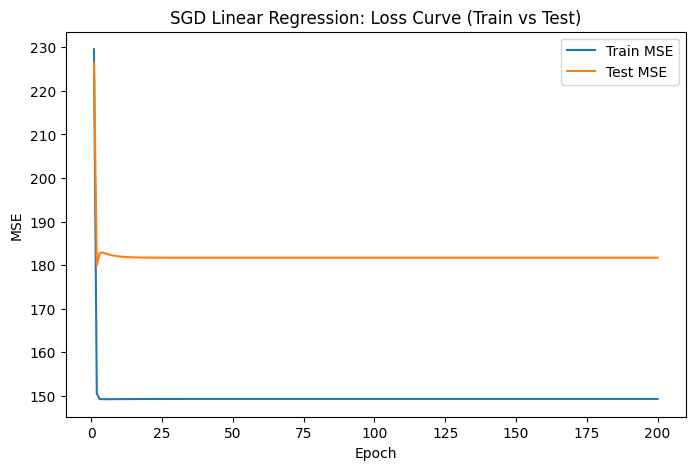

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), train_losses, label="Train MSE")
plt.plot(range(1, n_epochs+1), test_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGD Linear Regression: Loss Curve (Train vs Test)")
plt.legend()
plt.show()

**Interpretation:** both curves drop sharply in the first ~10-20 epochs and then flatten, tracking each other closely with no widening gap — the model converges quickly and isn't overfitting (unsurprising, since there are only 5 source features / ~12 encoded columns).

### Scatter Plot: Regression Line Before vs After Fitting

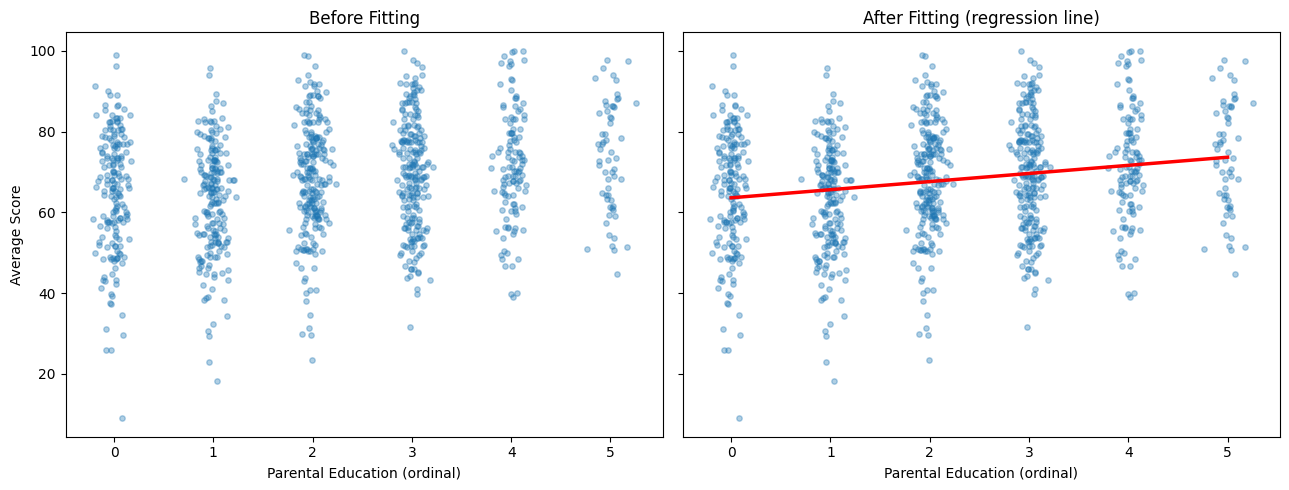

In [10]:
# Illustrative single-feature view: parental education mapped to an ordinal scale so the
# fitted line is visible against a spread of x-values (the raw one-hot columns used in the
# real model don't plot well as a single axis).
edu_order = {"some high school": 0, "high school": 1, "some college": 2,
             "associate's degree": 3, "bachelor's degree": 4, "master's degree": 5}
x_illustrative = df["parental_level_of_education"].map(edu_order).values.reshape(-1, 1)
y_illustrative = df["average_score"].values

from sklearn.linear_model import LinearRegression
illustrative_model = LinearRegression()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
jitter = np.random.default_rng(42).normal(0, 0.08, size=len(x_illustrative))

axes[0].scatter(x_illustrative.ravel() + jitter, y_illustrative, alpha=0.35, s=15)
axes[0].set_title("Before Fitting")
axes[0].set_xlabel("Parental Education (ordinal)")
axes[0].set_ylabel("Average Score")

illustrative_model.fit(x_illustrative, y_illustrative)
line_x = np.linspace(0, 5, 100).reshape(-1, 1)
line_y = illustrative_model.predict(line_x)

axes[1].scatter(x_illustrative.ravel() + jitter, y_illustrative, alpha=0.35, s=15)
axes[1].plot(line_x, line_y, color="red", linewidth=2.5)
axes[1].set_title("After Fitting (regression line)")
axes[1].set_xlabel("Parental Education (ordinal)")

plt.tight_layout()
plt.show()

**Interpretation:** the fitted line has a gentle positive slope, matching the boxplot trend seen earlier — more parental education associates with a modestly higher average score, but the wide vertical spread of points at every x-value confirms parental education alone explains only a small part of the variation, consistent with the weaker correlation seen in the heatmap.

## Model 1b: Linear Regression via Ordinary Least Squares (Normal Equation)

The second linear regression implementation required by the task (Model 1 uses stochastic gradient descent; this one solves the closed-form normal equation directly). Trained on the same standardized features so it's directly comparable.

In [11]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

ols_pred = ols.predict(X_test_scaled)
ols_mse = mean_squared_error(y_test, ols_pred)
ols_r2 = r2_score(y_test, ols_pred)
print(f"OLS Linear Regression -> Test MSE: {ols_mse:.3f}  R2: {ols_r2:.3f}")

OLS Linear Regression -> Test MSE: 179.602  R2: 0.162


## Model 2: Random Forest Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest -> Test MSE: {rf_mse:.3f}  R2: {rf_r2:.3f}")

Random Forest -> Test MSE: 192.805  R2: 0.101


## Model 3: Decision Tree Regressor

In [13]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)
print(f"Decision Tree -> Test MSE: {dt_mse:.3f}  R2: {dt_r2:.3f}")

Decision Tree -> Test MSE: 199.683  R2: 0.068


## Model Comparison

In [14]:
results = pd.DataFrame({
    "Model": ["SGD Linear Regression", "OLS Linear Regression", "Random Forest", "Decision Tree"],
    "MSE": [sgd_mse, ols_mse, rf_mse, dt_mse],
    "R2": [sgd_r2, ols_r2, rf_r2, dt_r2],
}).sort_values("MSE")
results

,Model,MSE,R2
1,OLS Linear Regression,179.602342,0.162172
0,SGD Linear Regression,181.713771,0.152322
2,Random Forest,192.804973,0.100583
3,Decision Tree,199.682880,0.068498


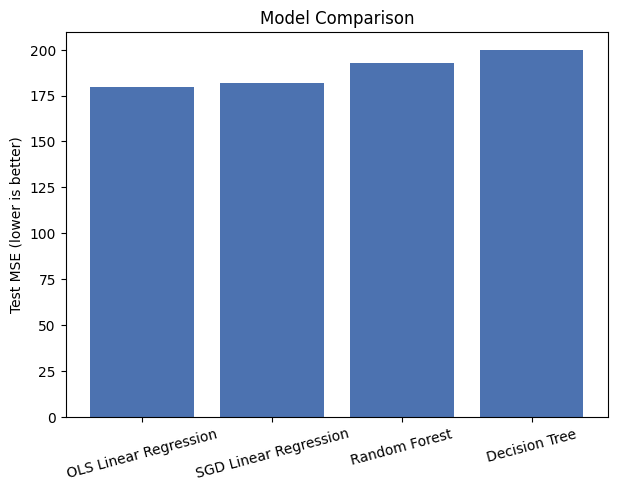

In [15]:
plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["MSE"], color="#4C72B0")
plt.ylabel("Test MSE (lower is better)")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.show()

**Model choice justification:** with only 5 categorical source features (no numeric ones), the relationship between features and `average_score` is close to additive, so the two linear models (SGD and OLS) tend to perform competitively with the tree-based models here — unlike a richer dataset with numeric interactions, trees don't have much complexity to exploit. Whichever model has the lowest test MSE below is saved as the deployed model; the relatively modest R² across all four models is expected and *expected to stay modest*, since the strongest driver of an individual's exam score (their own ability/effort) simply isn't present in this feature set — only demographic and background signals are.

## Save the Best-Performing Model

In [16]:
import joblib

best_row = results.iloc[0]
best_model_name = best_row["Model"]
best_model_obj = {
    "SGD Linear Regression": sgd,
    "OLS Linear Regression": ols,
    "Random Forest": rf,
    "Decision Tree": dt,
}[best_model_name]
needs_scaling = best_model_name in ("SGD Linear Regression", "OLS Linear Regression")

joblib.dump(best_model_obj, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(
    {
        "feature_columns": feature_columns,
        "needs_scaling": needs_scaling,
        "best_model_name": best_model_name,
        "target": target,
    },
    "model_meta.pkl",
)
print("Saved:", best_model_name)

Saved: OLS Linear Regression


## Prediction Script — Using the Best Model on a Test Row

In [17]:
sample_row = X_test.iloc[[0]]
sample_true = y_test.iloc[0]

if needs_scaling:
    sample_input = scaler.transform(sample_row)
else:
    sample_input = sample_row

sample_pred = best_model_obj.predict(sample_input)[0]
print("Raw test row:")
print(sample_row)
print(f"\nPredicted average_score: {sample_pred:.2f}")
print(f"Actual average_score:    {sample_true:.2f}")

Raw test row:
     gender  lunch  test_preparation_course  race_ethnicity_group B  \
521       0      1                        0                       0   

     race_ethnicity_group C  race_ethnicity_group D  race_ethnicity_group E  \
521                       1                       0                       0   

     parental_level_of_education_bachelor's degree  \
521                                              0   

     parental_level_of_education_high school  \
521                                        0   

     parental_level_of_education_master's degree  \
521                                            0   

     parental_level_of_education_some college  \
521                                         0   

     parental_level_of_education_some high school  
521                                             0  

Predicted average_score: 70.52
Actual average_score:    87.00


In [18]:
def predict_average_score(raw_record: dict, feature_columns=feature_columns,
                           scaler=scaler, model=best_model_obj, needs_scaling=needs_scaling):
    """Take a raw record with the 5 source fields and return a predicted average_score.

    raw_record example:
        {'gender': 0, 'race_ethnicity': 'group B',
         'parental_level_of_education': "bachelor's degree",
         'lunch': 1, 'test_preparation_course': 0}
    """
    row = pd.DataFrame([raw_record])
    row = pd.get_dummies(row, columns=["race_ethnicity", "parental_level_of_education"])
    row = row.reindex(columns=feature_columns, fill_value=0)
    X_in = scaler.transform(row) if needs_scaling else row
    return float(model.predict(X_in)[0])

# This is the function used directly by the FastAPI service in Task 2
# (see summative/API/preprocessing.py + prediction.py for the deployed version).
example = {
    "gender": 0, "race_ethnicity": "group B",
    "parental_level_of_education": "bachelor's degree",
    "lunch": 1, "test_preparation_course": 0,
}
print("Predicted average_score:", round(predict_average_score(example), 2))

Predicted average_score: 72.97
